In [1]:
# Importing libraries
import numpy as np

from scipy.special import factorial, eval_hermite
from scipy.constants import hbar, electron_mass, electron_volt
from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
plt.style.use("dark_background")

In [2]:
# OOP code
class QuantumOscillator:
    def __init__(self, m, omega, n):
        self.m = m
        self.omega = omega
        self.n = n
        self.l = np.sqrt(hbar / (self.m * self.omega))
        self.turn = np.sqrt(2 * self.n + 1) * self.l # Turning point
        self.x = np.linspace(- 5 * self.turn, 5 * self.turn, 50_000)

        self.energy = hbar * omega * (self.n + 0.5) / electron_volt # Energies in eV
        self.wavefunction = ((1 / np.sqrt(2 ** self.n * factorial(self.n)) * (m * omega / (np.pi * hbar)) ** 0.25) * np.exp(- (m * omega * self.x ** 2) / (2 * hbar)) * eval_hermite(self.n, self.x * np.sqrt(m * omega / hbar))) # Wavefunctions

    def plot(self): # Plot the wave function
        plt.figure(figsize = (7, 7))
        plt.plot(self.x,
                 self.wavefunction, 
                 color = 'cyan', 
                 linewidth = 2,
                 label = f'ψ_{self.n}(x)')
        plt.axvline(self.turn,
                    color = 'red',
                    linestyle = '--',
                    alpha = 0.5, 
                    label = f'Turning point: ±{self.turn:.0e} m')
        plt.axvline(-self.turn,
                    color = 'red',
                    linestyle = '--',
                    alpha = 0.5)
        
        # Shade the classically forbidden regions
        mask_forbidden_left = self.x < -self.turn
        mask_forbidden_right = self.x > self.turn
        plt.fill_between(self.x[mask_forbidden_left], 
                         self.wavefunction[mask_forbidden_left].min(), 
                         self.wavefunction[mask_forbidden_left].max(),
                         alpha = 0.25,
                         color = 'red',
                         label = 'Classically forbidden region')
        plt.fill_between(self.x[mask_forbidden_right], 
                         self.wavefunction[mask_forbidden_right].min(), 
                         self.wavefunction[mask_forbidden_right].max(),
                         alpha = 0.25,
                         color='red')
        
        plt.xlabel('Position x [m]', fontsize = 12)
        plt.ylabel('Wavefunction ψ(x)', fontsize = 12)
        plt.title(f'Harmonic Oscillator Wavefunction (n={self.n}) \n' f' E = {self.energy:.3f} eV', fontsize = 14)
        plt.grid(True, alpha = 0.3)
        plt.legend(loc = 'best')
        plt.tight_layout()
        plt.show()
        return None

    def plot2(self): # Plot the probability density
        plt.figure(figsize = (7, 7))
        plt.plot(self.x,
                 self.wavefunction ** 2, 
                 color = 'yellow', 
                 linewidth = 2,
                 label = f'|ψ_{self.n}(x)|²')
        plt.axvline(self.turn,
                    color = 'red',
                    linestyle = '--',
                    alpha = 0.5, 
                    label = f'Turning point: ±{self.turn:.0e} m')
        plt.axvline(- self.turn,
                    color = 'red',
                    linestyle = '--',
                    alpha = 0.5)
        
        # Shade the probability in forbidden regions
        mask_forbidden_left = self.x < -self.turn
        mask_forbidden_right = self.x > self.turn
        plt.fill_between(self.x[mask_forbidden_left], 
                         np.zeros_like(self.x[mask_forbidden_left]),
                         (self.wavefunction ** 2)[mask_forbidden_left],
                         alpha = 0.25,
                         color = 'red',
                         label = f'Tunneling probability: {self.tunnel_prob():.2f}%')
        plt.fill_between(self.x[mask_forbidden_right], 
                         np.zeros_like(self.x[mask_forbidden_right]),
                         (self.wavefunction ** 2)[mask_forbidden_right],
                         alpha = 0.25,
                         color='red')
        
        plt.xlabel('Position x [m]', fontsize = 12)
        plt.ylabel('Probability Density |ψ(x)|²', fontsize = 12)
        plt.title(f'Harmonic Oscillator Probability Density (n={self.n})', fontsize = 14)
        plt.grid(True, alpha = 0.3)
        plt.legend(loc = 'best')
        plt.tight_layout()
        plt.show()
        return None
    
    def check_norm(self): # Check if the wavefunction is normalized [%]
        return 100 * trapezoid(self.wavefunction ** 2, self.x)
        
    def tunnel_prob(self): # Compute tunneling effect [%]
        return 200 * trapezoid(self.wavefunction[self.x > self.turn] ** 2, self.x[self.x > self.turn])

In [3]:
# Create an instance of QuantumOscillator class
q = QuantumOscillator(m = electron_mass, # Electron
                      omega = 1e+13,
                      n = 0) # Ground state

In [4]:
# Energy level [eV]
q.energy

0.003291059784754533

In [5]:
# Exact wavefunction for n = 0
q.wavefunction

array([0.04798823, 0.04803624, 0.0480843 , ..., 0.0480843 , 0.04803624,
       0.04798823], shape=(50000,))

In [6]:
# Check if the wavefunction is normalized
q.check_norm()

np.float64(99.99999999984628)

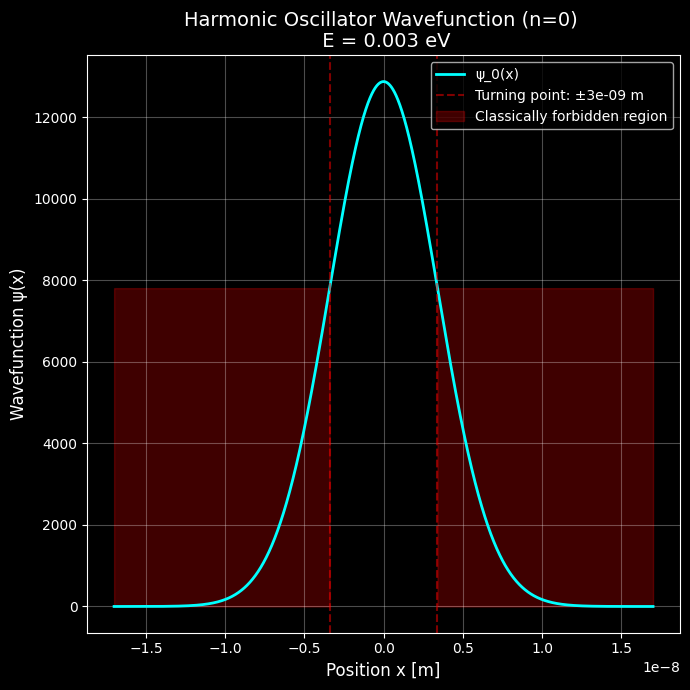

In [7]:
# Plotting psi
q.plot()

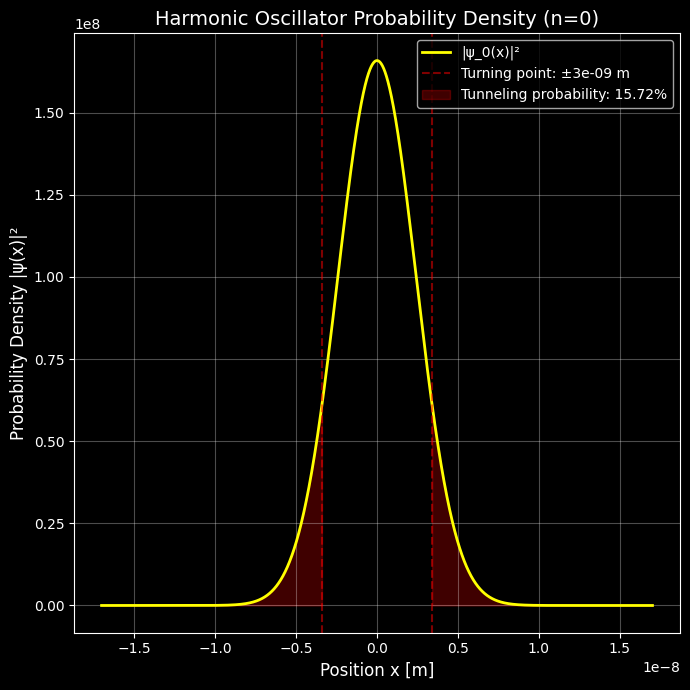

In [8]:
# Plotting the probability density psi^2
q.plot2()

In [9]:
# Tunnel effect probability [%]
q.tunnel_prob()

np.float64(15.724940189748903)

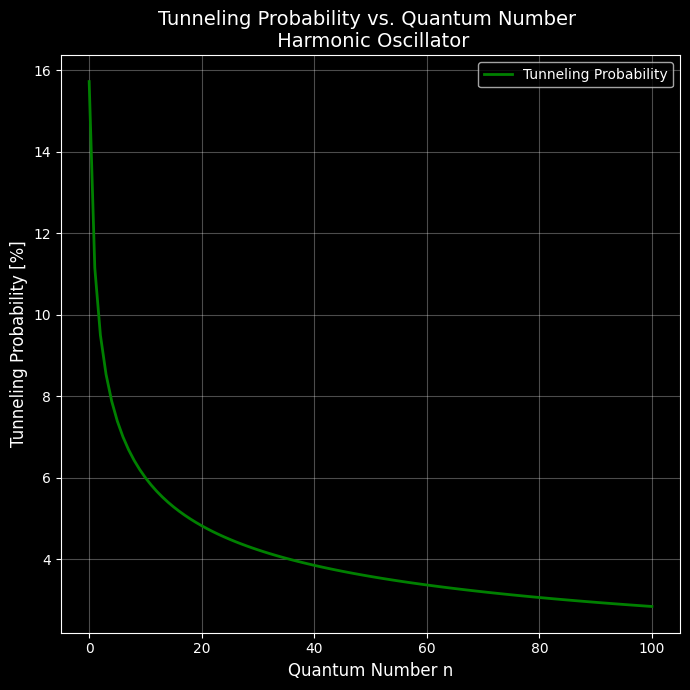

In [10]:
# Computing the probability chart
n_list = list(range(0, 101, 1)) # states from 0 to 100
tunnel_list = []

for n in n_list:
    q = QuantumOscillator(m = electron_mass,
                          omega = 1e+13,
                          n = n)
    tunnel_list.append(q.tunnel_prob())

plt.figure(figsize = (7, 7))
plt.plot(n_list, tunnel_list, 'g-', linewidth = 2, label = 'Tunneling Probability')
plt.xlabel('Quantum Number n', fontsize = 12)
plt.ylabel('Tunneling Probability [%]', fontsize = 12)
plt.title('Tunneling Probability vs. Quantum Number \n Harmonic Oscillator', fontsize = 14)
plt.grid(True, alpha = 0.3)
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()